In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel('year.xlsx')
print(df)

    paper   year
0        1  2021
1        2  2019
2        3  2022
3        4  2020
4        5  2021
..     ...   ...
95      96  2023
96      97  2023
97      98  2023
98      99  2023
99     100  2019

[100 rows x 2 columns]


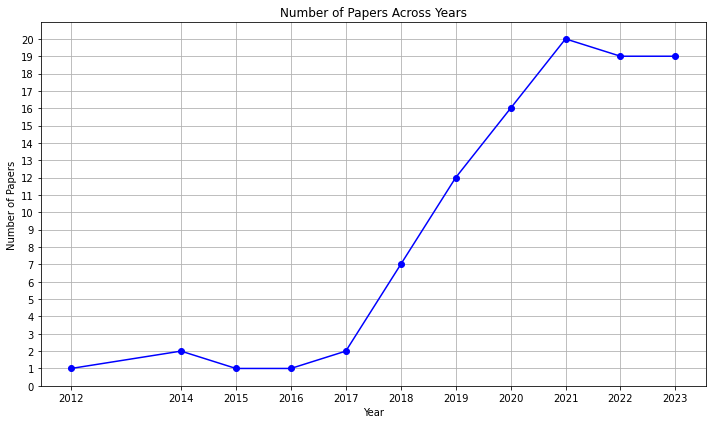

In [ ]:
import matplotlib.pyplot as plt
# Group by year and count the number of papers
papers_per_year = df.groupby('year').size()

# Plotting the line chart
plt.figure(figsize=(10, 6))
papers_per_year.plot(marker='o', color='b', linestyle='-')
plt.title('Number of Papers Across Years')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.grid(True)
plt.xticks(papers_per_year.index)  # Set x-axis ticks to years
plt.yticks(range(int(papers_per_year.max()) + 1))  # Set y-axis ticks as integers
plt.tight_layout()
plt.show()

In [ ]:
df["content"] = record

In [ ]:
df

,Name,content
0,paper 1,Healthcare Analytics 1 (2021) 100008\n\nConten...
1,paper 2,An Edge-based Architecture to Support Efﬁcient...
2,paper 3,1068638 JPCXXX10.1177/21501319211068638Journal...
3,paper 4,"Industry 4.0 and Health: Internet of Things, B..."
4,paper 5,Nuno Mateus-Coelho \nAdjunct Professor \nISLA ...
...,...,...
95,paper 96,Health and Technology (2023) 13:35–52 \nhttps:...
96,paper 97,Trustworthy Privacy-preserving Hierarchical\nE...
97,paper 98,Article\nSmart Chemical Sensor and Biosensor N...
98,paper 99,Hindawi\nInternational Journal of Intelligent ...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     100 non-null    object
 1   content  100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB


In [ ]:
df['content'][1]

'An Edge-based Architecture to Support Efﬁcient\nApplications for Healthcare Industry 4.0\n\nPasquale Pace, Member, IEEE, Gianluca Aloi, Member, IEEE, Raffaele Gravina, Member, IEEE,\nGiuseppe Caliciuri, Giancarlo Fortino, Senior Member, IEEE, and Antonio Liotta, Senior Member, IEEE\n\n1\n\nAbstract—Edge computing paradigm has attracted many in-\nterests in the last few years as a valid alternative to the standard\nCloud-based approaches to reduce the interaction timing and\nthe huge amount of data coming from IoT devices toward the\nInternet. In the next future, Edge-based approaches will be\nessential to support time-dependent applications in the Indus-\ntry 4.0 context; thus, the paper proposes BodyEdge, a novel\narchitecture well suited for human-centric applications, in the\ncontext of the emerging healthcare industry. It consists of a tiny\nmobile client module and a performing Edge gateway supporting\nmulti-radio and multi-technology communication to collect and\nlocally process

In [ ]:
import string
from nltk.corpus import stopwords

In [ ]:
#defining the function to remove punctuation
from nltk.tokenize import RegexpTokenizer
def remove_punctuation(text):
    text=text.replace("/n"," ")
    tokenizer = RegexpTokenizer(r"\w+")
    punctuationfree = tokenizer.tokenize(text)
    punctuationfree=" ".join([i for i in punctuationfree if i not in string.punctuation])
    return punctuationfree
#storing the puntuation free text
df['content']= df['content'].apply(lambda x:remove_punctuation(x))
df.head()

,Name,content
0,paper 1,Healthcare Analytics 1 2021 100008 Contents li...
1,paper 2,An Edge based Architecture to Support Efﬁcient...
2,paper 3,1068638 JPCXXX10 1177 21501319211068638Journal...
3,paper 4,Industry 4 0 and Health Internet of Things Big...
4,paper 5,Nuno Mateus Coelho Adjunct Professor ISLA Poly...


In [ ]:
df['content'][1]

'An Edge based Architecture to Support Efﬁcient Applications for Healthcare Industry 4 0 Pasquale Pace Member IEEE Gianluca Aloi Member IEEE Raffaele Gravina Member IEEE Giuseppe Caliciuri Giancarlo Fortino Senior Member IEEE and Antonio Liotta Senior Member IEEE 1 Abstract Edge computing paradigm has attracted many in terests in the last few years as a valid alternative to the standard Cloud based approaches to reduce the interaction timing and the huge amount of data coming from IoT devices toward the Internet In the next future Edge based approaches will be essential to support time dependent applications in the Indus try 4 0 context thus the paper proposes BodyEdge a novel architecture well suited for human centric applications in the context of the emerging healthcare industry It consists of a tiny mobile client module and a performing Edge gateway supporting multi radio and multi technology communication to collect and locally process data coming from different scenarios moreover

In [ ]:
df['content']= df['content'].apply(lambda x: x.lower())

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
lemmatizer = WordNetLemmatizer()
#A function which takes a sentence/corpus and gets its lemmatized version.
def lemmatizeSentence(sentence):
    token_words=word_tokenize(sentence)
#we need to tokenize the sentence or else lemmatizing will return the entire sentence as is.
    lemma_sentence=[]
    for word in token_words:
        lemma_sentence.append(lemmatizer.lemmatize(word))
        lemma_sentence.append(" ")
    return "".join(map(str,lemma_sentence))

In [ ]:
df["content"] = df["content"].apply(lambda text: lemmatizeSentence(text))

In [ ]:
stopw=[]
#open text file
with open('stopwords.txt','r') as file:

    # reading each line
    for line in file:

        # reading each word
        for word in line.split():

            # displaying the words
            stopw.append(word)

In [ ]:
STOPWORDS = set(stopwords.words('english'))
medstop={"ieee","doi","orthopaedic","orthopaedics","industry","epidemiologist","quarantine","infection","system","row","vaccines" "column","abstract","methodology","literature","review","result","conclusion","references"}
STOPWORDS.update(medstop)
STOPWORDS.update(stopw)
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df["content"] = df["content"].apply(lambda text: remove_stopwords(text))

In [ ]:
STOPWORDS

{'drug',
 'summat',
 'behinds',
 'ehr',
 'gastroenterology',
 'Sports',
 'three',
 'these',
 'else',
 'inc',
 'disabilities',
 'waste',
 'do',
 's',
 'should',
 'cure',
 'appears',
 'Hand',
 'don',
 'conditions',
 'natheless',
 'withal',
 'Neuropathology',
 'maternal',
 'provided',
 'main',
 'figuponed',
 'Research',
 'ourself',
 'seemings',
 'mights',
 'pills',
 'getting',
 'calf',
 'oftener',
 'aller',
 'variouser',
 'arrhythmia',
 'often',
 'physicians',
 'since',
 'availablest',
 'particularer',
 'provides',
 'buts',
 'rectal',
 'cantest',
 'though',
 'samest',
 'use',
 'sans',
 'howbeit',
 'idem',
 'arch',
 'hadn',
 'Brain',
 'neaths',
 'inasmuch',
 'senza',
 'appropriating',
 'differentest',
 'pregnancy',
 'Psychiatric',
 'will',
 'towards',
 'Oculoplastics',
 'bone',
 'woulding',
 'failure',
 'whether',
 'described',
 'wherewith',
 'downwardest',
 'genetic',
 'Neuroradiology',
 'shalled',
 'fact',
 'serious',
 'albeit',
 'at',
 'frae',
 'thence',
 'astride',
 'fourscore',
 'Immu

In [ ]:
df['content'][2]

'1068638 jpcxxx10 1177 21501319211068638journal primary community healthsarfraz al article commentary2021 commentary 4 0 manufacturing distribution 19 primary community volume 13 1 5 author 2022 article reuse guideline sagepub permission 10 1177 21501319211068638 org 10 1177 21501319211068638 sagepub home jpc zouina sarfraz1 3 azza sarfraz1 2 aminah abdul razzack1 shehar bano3 sindhu thevuthasan1 trissa paul1 muhammad khawar sana1 nishwa azeem5 miguel felix6 7 ivan cherrez ojeda6 7 muzna sarfraz1 4 sarabjot singh makkar1 background evolutionary stage manufacturing led conceptualize 4 0 19 2019 powered 4 0 using application integrated process optimization reliant digitized propose novel intelligent network value chain 4 0 may enable maintenance process streamline logistics enable optimal production 19 4 0 framework applying 4 0 includes requirement large scale digitally transforming manufacturing producing rolling distributing framework 4 0 analytics target process performance process d

In [ ]:
import re
df['content'] = df['content'].apply(lambda x: re.sub("\d",' ',x))
df['content'] = df['content'].apply(lambda x:' '.join( [w for w in x.split() if len(w)>2]))

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
d=Counter(" ".join(df["content"]).split()).most_common(70)
f=dict(d)
f

{'based': 2482,
 'blockchain': 2282,
 'model': 2069,
 'service': 2015,
 'application': 1868,
 'cloud': 1848,
 'iot': 1610,
 'network': 1558,
 'process': 1533,
 'using': 1451,
 'smart': 1410,
 'sensor': 1303,
 'management': 1275,
 'study': 1238,
 'computing': 1185,
 'security': 1128,
 'digital': 1123,
 'proposed': 1118,
 'analysis': 1080,
 'value': 1076,
 'record': 1071,
 'vol': 1022,
 'access': 970,
 'big': 965,
 'performance': 937,
 'internet': 929,
 'method': 908,
 'learning': 887,
 'user': 885,
 'approach': 880,
 'paper': 872,
 'algorithm': 855,
 'case': 849,
 'human': 814,
 'block': 797,
 'robot': 792,
 'manufacturing': 790,
 'may': 783,
 'monitoring': 782,
 'need': 782,
 'solution': 782,
 'org': 774,
 'level': 770,
 'framework': 761,
 'work': 758,
 'machine': 752,
 'table': 745,
 'key': 741,
 'number': 714,
 'fig': 706,
 'real': 705,
 'transaction': 702,
 'cost': 701,
 'decision': 694,
 'future': 689,
 'chain': 676,
 'communication': 668,
 'resource': 659,
 'issue': 658,
 'support

<BarContainer object of 70 artists>

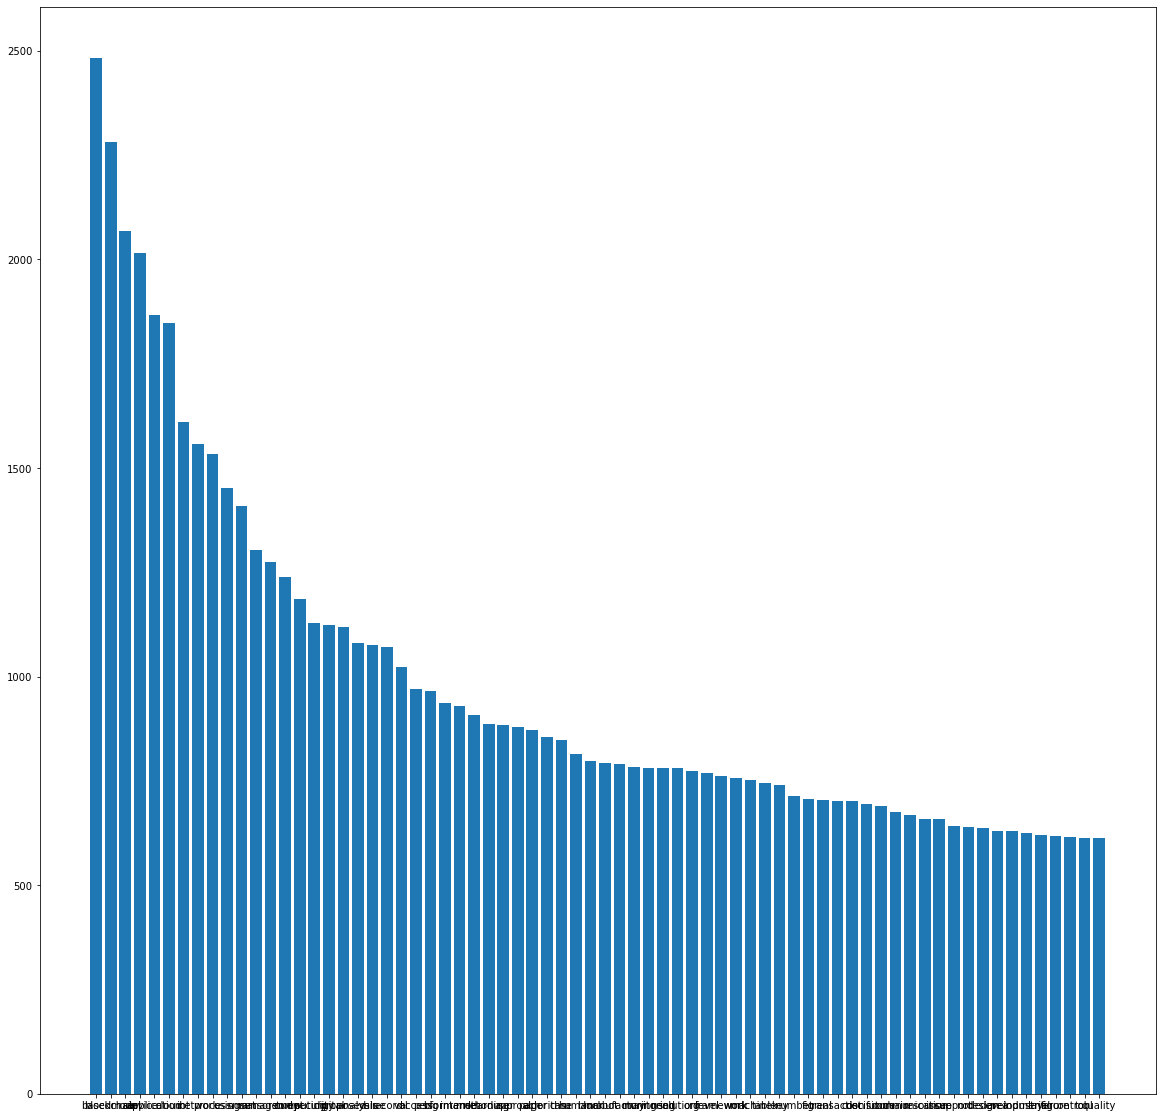

In [ ]:
names = list(f.keys())
values = list(f.values())
plt.figure(figsize=(20,20))
plt.bar(range(len(f)), values, tick_label=names)

In [ ]:
df["content"][1]

'edge based architecture support efﬁcient application pasquale pace member gianluca aloi member raffaele gravina member giuseppe caliciuri giancarlo fortino senior member antonio liotta senior member edge computing paradigm attracted terests last year valid alternative standard cloud based approach reduce interaction timing huge amount coming iot internet next future edge based approach essential support dependent application indus try context paper proposes bodyedge novel architecture well suited human centric application context emerging consists tiny mobile client module performing edge gateway supporting multi radio multi communication collect locally process coming scenario exploit facility made private public cloud platform guarantee high ﬂexibility robustness adaptive service level advantage designed software platform evaluated term reduced transmitted processing real implementation hardware platform conducted study highlighted network load processing delay bodyedge valid inexpe

In [ ]:
from keybert import KeyBERT

In [ ]:
kw_model = KeyBERT(model='all-mpnet-base-v2')

In [ ]:
df['content_new']=df['content']

In [ ]:
for i in range(0,100):
    keywords = kw_model.extract_keywords(df['content'][i],keyphrase_ngram_range=(1, 2),highlight=False, top_n=70)
    keywords_list= list(dict(keywords).keys())
    s=""
    for kw in keywords_list:
        print(kw)
        s=s+" "+kw
    df['content_new'][i]=s
    print(" ")
    print(i)
    print(" ")

digital revolution
digitalization big
digital transformation
emerging management
analytics
management science
management industrial
internet industrial
digitalization change
sustainability cyber
digitalization transformation
digitalization cyber
thematic analysis
digitalization analysis
paradigm emerging
management future
analysis study
emerging digital
network thematic
future impact
digitalization paradigm
virtualization digitalization
analysis employed
society digital
software emerging
disruptive transformation
analysis customer
publication analysis
innovation network
management project
management
bibliometric analysis
emerging technolo
engineering management
iot dominates
introduction impact
like iot
analytics alleviating
qualitative analysis
engineering manage
sector management
network analysis
martek analytics
applied sector
management intelligent
industrial revolution
digitalization internet
adoption digital
emerging paradigm
issue study
sustainability predictive
modernize produc

iot correspond
intelligence iot
iot standard
network iot
communication iot
iot artificial
iot network
iot addressed
layer iot
iot associated
speak iot
iot area
iot net
iot based
iot model
future iot
iot arrange
applying iot
iot eventually
iot
iot application
internet iot
iot encounter
answer iot
iot fundamental
communication internet
iot using
wireless communication
likewise iot
empowers iot
iot advancement
future wireless
arrangement iot
iot organize
iot need
interchange iot
iot iot
efficiency iot
based iot
finding iot
versatile iot
savvy iot
designed iot
wireless standard
quick iot
issue iot
iot module
using iot
iot ues
iot enabled
encounter iot
network future
iot duced
network communication
iot calcu
assisted iot
working iot
range iot
iot brings
iot gadget
iot class
iot saddoud
learning iot
domain iot
iot framework
improving iot
management iot
permit iot
iot traditional
iot reveals
 
7
 
metabolic application
sciencedirect metabolic
metabolic
metabolic content
metabolic table
metabo

bioinformatics genome
application bioinformatics
bioinformatics hadoop
genome sequence
bioinformatics iot
genome analysis
dna sequencing
genomic
analysis genome
sequence bioinformatics
genomics study
genome sequencing
genome database
bioinformatics tool
dna sequenced
genomics
mining genome
genomic sequence
dna sequence
computing genome
bioinformatics integration
bioinformatics
genome
database genome
matching genome
field bioinformatics
genome intriguing
big genomics
bioinformatics aim
sequencing dna
hadoopcl genome
efficient genomic
gene sequence
advancement bioinformatics
genomics genuine
datasets genome
human genome
monitoring genome
bioinformatics section
mapped genome
biopig hadoop
given genome
genome organism
bioinformatics include
genome string
role bioinformatics
quantity genome
process genome
bioinformatics acad
work genome
genome acceptable
sequencing matching
bioinformatics guo
biological sequence
genomic broadly
understanding genomics
field genome
genome following
api genome

cryptography blockchain
network blockchain
blockchain based
blockchain network
blockchain propose
blockchain support
using blockchain
blockchain smart
propose blockchain
keywords blockchain
blockchain cryptocurrency
blockchain need
cryptosystem blockchain
blockchain
blockchain proposed
blockchain infrastructure
situation blockchain
advantage blockchain
application blockchain
ethereum blockchain
blockchain technol
rectly blockchain
smart ledger
blockchain platform
blockchain approach
blockchain electronic
blockchain potential
blockchain blockchain
proposing blockchain
blockchains support
eﬃcient blockchain
platform blockchain
form blockchain
facility blockchain
smart contract
based blockchain
delivery blockchain
formance blockchain
intelligence blockchain
blockchain able
overview blockchain
relating blockchain
blockchain framework
integrating blockchain
assessment blockchain
blockchain poslad
proposed blockchain
blockchain ﬁrst
develop blockchain
hyperledger blockchain
provider blockcha

robotics proposing
robotics big
robotics deeply
robotics
industrial robot
industrial robotics
robotics far
robotics artificial
application botics
robot
proposed robotics
robotic
expert robotics
year robotic
robot created
autonomous robot
robotics barcelona
robotics maker
case robot
robot automate
robot integrated
artificial intelligence
ibm artificial
artificial intelli
intelligence printing
automation
robot year
including robotics
neural network
isfaction robot
vehicle robot
watson ibm
robot present
dious robot
robot deployed
machine learning
robot crogrippers
empowering assistant
artificially intelligent
printing robotics
food robot
application emerging
casiopea robotics
accelerating automation
robot perform
algorithm developed
interactive robot
automation process
predict concept
intelligent diagno
workflow industrial
guideline machine
intelligence cloud
robot aethon
developed wearable
task prosthetics
vita robot
learning algorithm
bring robotic
technological
botics
autonomous
roboti

...

develop robotic
robotic develop
regard robotic
robotic company
robot work
robotic developed
robotic future
robotic operation
robotic experience
robotic innovation
robotic sector
work robot
robotic operate
developing robotic
development robotic
production robotic
introduction robotic
categorizing robotic
robot developed
robotic situation
produce robotic
robot using
society robotic
existing robotic
robotized work
categorize robotic
keywords robotic
robot future
developed robotic
robotic relation
future robotic
robot manufacturer
robotic safer
stakeholder robotic
robotic technical
ethic robot
important robotic
robotic promising
iot robotic
application robotic
robot categorized
intelligence robotic
management robotic
robotik betreuung
purpose robotic
design robotic
producing robotic
robotic categorized
robot creation
human robotic
robotic professional
robotic prototype
robotic market
sell robotic
using robotic
current robotic
robotic desirable
robot interface
robotics ﬁnal
professional rob

informatics europe
ehealth france
european ehealth
ehealth europe
digitalisation sector
ehealth european
computer france
development ehealth
ehealth innovation
database france
european implementation
ehealth development
ehealth french
europe implementation
ehealth infrastructure
cooperation european
implementation france
digitalisation
country ehealth
french electronic
confidentiality electronic
progress european
infrastructure implementation
implementation ehealth
telemedicine
possibility ehealth
ehealth network
digital development
government implement
smartphones online
european community
european survey
application telemedicine
term ehealth
cedex france
ehealth exchange
keywords electronic
ehealth exploratory
field ehealth
national ehealth
centric ehealth
telemedicine online
ehealth service
interoperable ehealth
french implementation
informatics staffa
ehealth application
informatics
european progress
digitalisation process
generally ehealth
electronic record
implementation electron

circular economy
sustainable circular
innovation circular
circular business
digital transformation
economy sustainability
sustainable business
digital sector
conservation recycling
circularity resource
economy digital
digitalisation enabler
economy sustainable
creating sustainable
adopting circular
environmental sustainability
europe recycling
created digitalisation
digitalisation
reponen digitalisation
manufacturing circular
economic environmental
digital involvement
digitalisation track
remanufacture recycle
sustainability
digitalization
catalyzing business
manufacturing innovation
remanufacture recycling
recycling
digitalization support
reuse recycling
facilitates recycling
economy ecology
recycling remanufacturing
concept sustainable
reponen digitalization
lifecycle product
recycling reduces
production circular
sustainability chauhan
iot sector
lifecycle iot
centric product
digital manufacturing
sustainable value
recycle sector
iot contributes
digital iot
manufacturing internet
sus

implementation adoption
adoption sector
sustainable development
sustainable organisational
analytics general
analytics electronic
informatics
general analytics
informatics org
analytics development
infrastructure required
mainstream implementing
analytics
internet model
requirement proposed
internet advancement
org topic
implementation
sustainability
adoption enabled
development goal
concern implementing
sustainable transition
iot predominately
proposed framework
access revolutionized
implementation potential
phone leveraging
agenda sustainable
internet platform
smart org
adoption reorganizing
big analytics
organisational
adoption systematic
management organization
dynamic organizational
framework adopted
organization systematic
cluster researcher
iot based
sustainability dynamic
solution architecture
implementing
analytics bda
internet bda
utilization resource
decentralization operation
organisational performance
cloud computing
infrastructure
internet org
framework developed
computer

biosensor network
sensor biosensor
body monitoring
body sensor
biosensor
wearable sensor
monitor physiological
sensor biosen
bsn sensor
pubmed sensor
sensor bsn
biosensors work
biosensors wearable
biomedical processing
sensor wearable
using biomedical
blood sensor
bsns sensor
chemical sensor
smart sensor
introduce biomedical
detect physiological
wearable body
bsn biomedical
sensor monitoring
sweat monitoring
bio bsn
biosensors enter
smart chemical
biosensors detect
layer biomedical
designing bsn
sensor biosensors
sensor org
bioparameters bsn
biomedical service
application sensor
bsn analyzing
design bsn
bsn designing
wearable sweat
feature biomedical
sensor network
biomedical readout
biomedical processed
biosensors collect
body bionanosensor
sensor blood
bsn design
biomedical engineering
physiological measurement
sensor insight
circulation sensor
sensor artiﬁcial
network sensor
sensor making
biosensors sample
biosensors proposed
sensor body
biosensors ﬂow
collect physiological
sensor r

In [ ]:
d=Counter(" ".join(df["content_new"]).split()).most_common(25)
f=dict(d)
f

{'iot': 861,
 'blockchain': 776,
 'cloud': 279,
 'smart': 207,
 'manufacturing': 205,
 'industrial': 195,
 'service': 155,
 'analytics': 154,
 'sensor': 143,
 'lean': 142,
 'based': 136,
 'management': 131,
 'robot': 127,
 'application': 110,
 'intelligence': 105,
 'computing': 99,
 'privacy': 96,
 'robotic': 95,
 'wearable': 94,
 'innovation': 90,
 'internet': 88,
 'digital': 87,
 'sustainable': 86,
 'logistics': 86,
 'network': 80}

<BarContainer object of 25 artists>

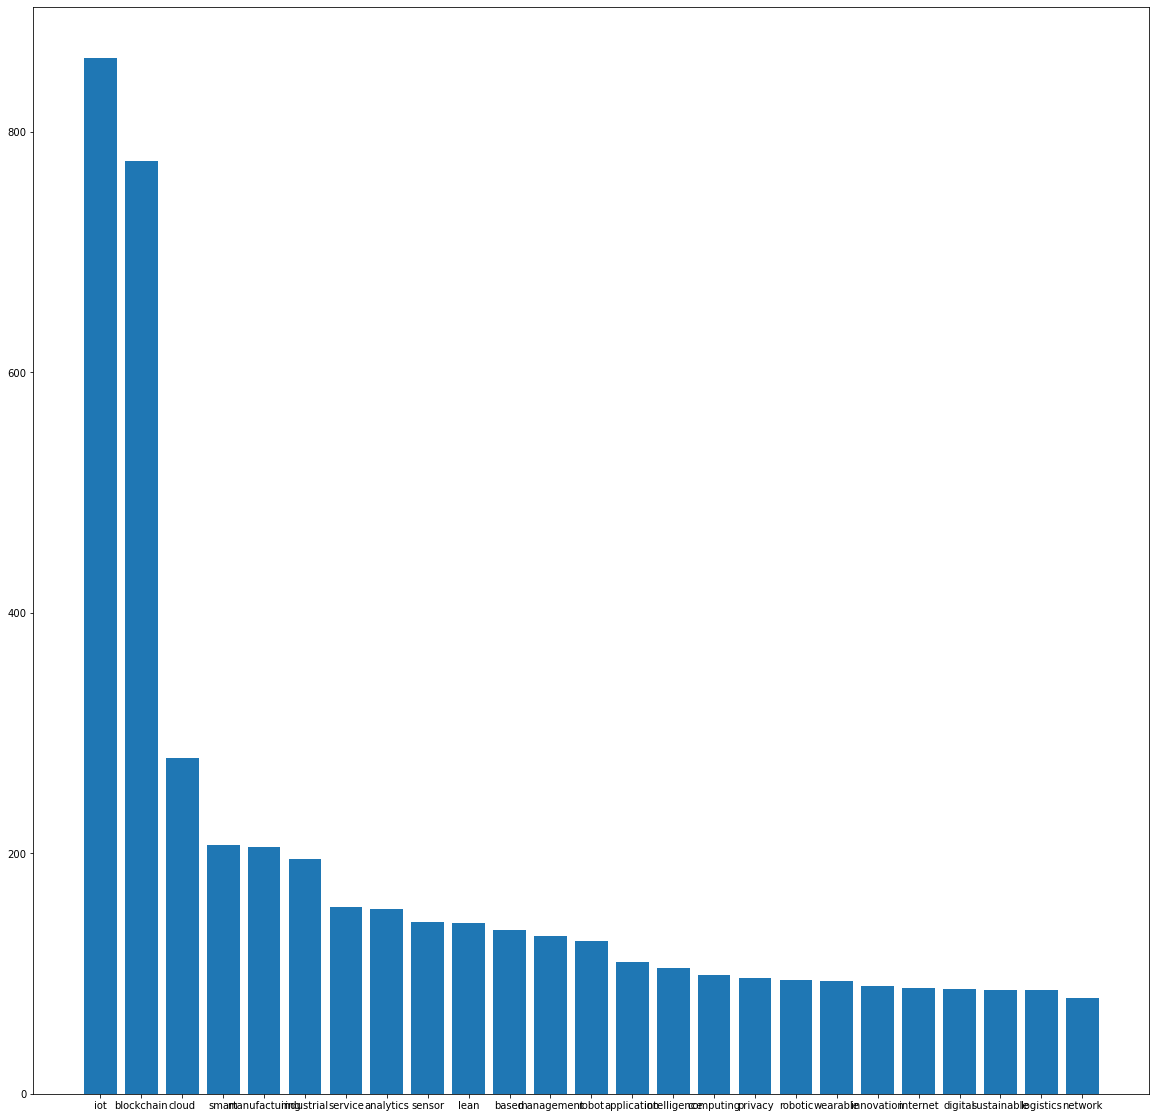

In [ ]:
names = list(f.keys())
values = list(f.values())
plt.figure(figsize=(20,20))
plt.bar(range(len(f)), values, tick_label=names)

In [ ]:
df

,Name,content,content_new
0,paper 1,analytics content list sciencedirect analytics...,digital revolution digitalization big digital...
1,paper 2,edge based architecture support efﬁcient appli...,edge computing iot cloud edge iot edge infras...
2,paper 3,jpcxxx journal primary community healthsarfraz...,transforming manufacturing manufacturing dist...
3,paper 4,internet big cloud computing giuseppe aceto va...,ehealth ecosystem revolutionizing ehealth com...
4,paper 5,nuno mateus coelho adjunct professor isla poly...,education mobile mobile education education a...
...,...,...,...
95,paper 96,org paper impact low middle income country sys...,digital africa developing country delivering ...
96,paper 97,trustworthy privacy preserving hierarchical en...,privacy blockchain centralized privacy intell...
97,paper 98,article smart chemical sensor biosensor networ...,biosensor network sensor biosensor body monit...
98,paper 99,hindawi international intelligent volume artic...,cloud auditing auditing cloud security cloud ...


In [ ]:
x_train=df['content_new'].to_numpy()

In [ ]:
x_train

array([' digital revolution digitalization big digital transformation emerging management analytics management science management industrial internet industrial digitalization change sustainability cyber digitalization transformation digitalization cyber thematic analysis digitalization analysis paradigm emerging management future analysis study emerging digital network thematic future impact digitalization paradigm virtualization digitalization analysis employed society digital software emerging disruptive transformation analysis customer publication analysis innovation network management project management bibliometric analysis emerging technolo engineering management iot dominates introduction impact like iot analytics alleviating qualitative analysis engineering manage sector management network analysis martek analytics applied sector management intelligent industrial revolution digitalization internet adoption digital emerging paradigm issue study sustainability predictive moderni

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
tf_idf_vectorizer=TfidfVectorizer()

cv_vectorizer= CountVectorizer(max_df=0.7)

In [ ]:
tf_idf_arr= tf_idf_vectorizer.fit_transform(x_train)

cv_arr=cv_vectorizer.fit_transform(x_train)

In [ ]:
tf_idf_arr

<100x2141 sparse matrix of type '<class 'numpy.float64'>'
	with 6352 stored elements in Compressed Sparse Row format>

In [ ]:
vocab_tf_idf=tf_idf_vectorizer.get_feature_names()

vocab_tf_idf

['abdellatif',
 'ability',
 'able',
 'acad',
 'academic',
 'accelerate',
 'accelerating',
 'acceleration',
 'accenture',
 'acceptability',
 'acceptable',
 'acceptance',
 'access',
 'accessed',
 'according',
 'account',
 'accountability',
 'accumulation',
 'accuracy',
 'accurate',
 'achieve',
 'achieves',
 'achieving',
 'acknowledgement',
 'acquired',
 'acquisi',
 'activity',
 'acute',
 'adapt',
 'adaptation',
 'adaptive',
 'add',
 'add_clinician',
 'adding',
 'addition',
 'additionally',
 'address',
 'addressed',
 'addressing',
 'adherence',
 'administration',
 'administrative',
 'adopt',
 'adopted',
 'adopting',
 'adoption',
 'adopts',
 'advance',
 'advanced',
 'advancement',
 'advantage',
 'advent',
 'adversarial',
 'advocating',
 'aerial',
 'aethon',
 'affected',
 'affecting',
 'aforementioned',
 'africa',
 'african',
 'age',
 'agency',
 'agenda',
 'agent',
 'aggregation',
 'agriculture',
 'ahead',
 'aided',
 'aim',
 'alexnet',
 'algorithm',
 'algorithmes',
 'alimadad',
 'alleviatin

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model= LatentDirichletAllocation(n_components=7, max_iter = 30, random_state=20)

X_topics= lda_model.fit_transform(tf_idf_arr)

topic_words=lda_model.components_

In [ ]:
import numpy as np

In [ ]:
n_top_words=10

for i, topic_dist in enumerate(topic_words):

    sorted_topic_dist = np.argsort(topic_dist)

    topic_words = np.array(vocab_tf_idf)[sorted_topic_dist]

    topic_words= topic_words[:-n_top_words:-1]
    print("topic", str(i+1), topic_words)
    print(" ")

topic 1 ['iot' 'blockchain' 'manufacturing' 'cloud' 'industrial' 'smart'
 'analytics' 'sensor' 'service']
 
topic 2 ['robot' 'resilience' 'genome' 'movie' 'bsn' 'agent' 'bioinformatics'
 'biosensors' 'resilient']
 
topic 3 ['uav' 'neurorehabilitation' 'education' 'uavs' 'robotic' 'exoskeleton'
 'robot' 'therapy' 'drone']
 
topic 4 ['lean' 'robot' 'printing' 'robotics' 'robotic' 'scheduling' 'homecare'
 'printer' 'operational']
 
topic 5 ['ehealth' 'pharmacy' 'robotization' 'perceptron' 'european' 'rural'
 'cybernetics' 'optimization' 'inventory']
 
topic 6 ['robotic' 'gdpr' 'biopharmaceutical' 'industry' 'biopharmachem' 'invent'
 'affected' 'worldwide' 'hazardous']
 
topic 7 ['competency' 'trust' 'imbalance' 'imbalanced' 'ehealth' 'brain'
 'insurance' 'auditing' 'disability']
 


In [ ]:
doc_topic=lda_model.transform(tf_idf_arr)

for n in range(doc_topic.shape[0]):

    topic_doc=doc_topic[n].argmax()

    print("document", n+1, " - - Topic: ", topic_doc+1)

document 1  - - Topic:  1
document 2  - - Topic:  1
document 3  - - Topic:  1
document 4  - - Topic:  1
document 5  - - Topic:  1
document 6  - - Topic:  1
document 7  - - Topic:  1
document 8  - - Topic:  1
document 9  - - Topic:  1
document 10  - - Topic:  1
document 11  - - Topic:  1
document 12  - - Topic:  1
document 13  - - Topic:  1
document 14  - - Topic:  1
document 15  - - Topic:  2
document 16  - - Topic:  1
document 17  - - Topic:  1
document 18  - - Topic:  1
document 19  - - Topic:  1
document 20  - - Topic:  1
document 21  - - Topic:  1
document 22  - - Topic:  1
document 23  - - Topic:  1
document 24  - - Topic:  2
document 25  - - Topic:  1
document 26  - - Topic:  7
document 27  - - Topic:  1
document 28  - - Topic:  4
document 29  - - Topic:  1
document 30  - - Topic:  1
document 31  - - Topic:  1
document 32  - - Topic:  1
document 33  - - Topic:  1
document 34  - - Topic:  1
document 35  - - Topic:  1
document 36  - - Topic:  1
document 37  - - Topic:  1
document 3

In [ ]:
for n in range(doc_topic.shape[0]):

    topic_doc=doc_topic[n].argmax()

    print("document", n+1, " - - Topic: ", topic_doc+1)

document 1  - - Topic:  1
document 2  - - Topic:  1
document 3  - - Topic:  1
document 4  - - Topic:  1
document 5  - - Topic:  1
document 6  - - Topic:  1
document 7  - - Topic:  1
document 8  - - Topic:  1
document 9  - - Topic:  1
document 10  - - Topic:  1
document 11  - - Topic:  1
document 12  - - Topic:  1
document 13  - - Topic:  1
document 14  - - Topic:  1
document 15  - - Topic:  2
document 16  - - Topic:  1
document 17  - - Topic:  1
document 18  - - Topic:  1
document 19  - - Topic:  1
document 20  - - Topic:  1
document 21  - - Topic:  1
document 22  - - Topic:  1
document 23  - - Topic:  1
document 24  - - Topic:  2
document 25  - - Topic:  1
document 26  - - Topic:  7
document 27  - - Topic:  1
document 28  - - Topic:  4
document 29  - - Topic:  1
document 30  - - Topic:  1
document 31  - - Topic:  1
document 32  - - Topic:  1
document 33  - - Topic:  1
document 34  - - Topic:  1
document 35  - - Topic:  1
document 36  - - Topic:  1
document 37  - - Topic:  1
document 3

In [ ]:
#open text file
text_file = open("data.txt", "w",  encoding='utf-8')

#write string to file
text_file.write(text1)

#close file
text_file.close()

In [ ]:
df['content']